# Homework: Build a StationXML Inventory for recent KSC deployment

Seven USF stations were deployed at Kennedy Space Center between January 7-12, 2026.
* Each features a Nanometrics Centaur digitizer, and a Nanometrics Trillium Compact Post-Hole 120-s seismometer.
* This is the same equipment we setup in our class a few weeks ago - except we also had infrasound.

Three additional seismic stations were setup by Marshall Space Flight Center, using Guralp and Silicon Audio equipment. You can ignore those for this exercise - or potentially earn some bonus points if you find responses for those too!

## Goal
Create a valid **StationXML** file for this small network using:
- Station coordinates stored in an **Excel** file
- Instrument responses pulled from the **IRIS Nominal Response Library (NRL)**

You will:
1. Load the station list with **pandas** into a pandas DataFrame
2. Create a Response object for a USF Nanometrics station
3. Build an ObsPy **Inventory**
4. Write out a **StationXML** file

> We're keeping it simple: one network, three channels per station (Z, N, E), same equipment at each site.

**Warning:** only attempt this homework after you have completed this week's reading exercises (notebooks 73 and 74)

## Provided file
Your station list is in:

- `Summary_Seismic_Station_List.xlsx`

One column contains photos — **ignore it**.

An alternative version of the Excel file is also provided as a Comma-Separated-Variable (CSV) text file, just in case you cannot read the Excel file. This is easier to read.

(If you open any Excel file with Excel, you can save it as a CSV).

## Make sure you have openpyxl installed in your conda environment!
This is required to read Excel files. CSV files will work without it.

In [88]:
import sys
#!conda install -y openpyxl --prefix {sys.prefix}

## Minimal pandas intro (what you need today)

**pandas** is a Python library for working with tables (“dataframes”).  
For this homework you only need to:
- read an Excel file
- select a few columns
- loop over rows

**Note**: you may need to install openpyxl in conda, and then restart this notebook/kernel. At the command line:

```
conda activate compsci # or whatever your conda env is
conda install openpyxml
```

In [150]:
import pandas as pd

xlsx_path = r"Summary_Seismic_Station_List.xlsx"
df = pd.read_excel(xlsx_path)

df.head(10)

,Site Name,GPS Coordinates,Photo,lat,lon,Notes,Digitizer,Seismometer,Infrasound
0,B01,"28°37'17""N 80°36'24""W",NaN,28.621389,-80.606667,Seismic (nanometrics) #271. Infrasound (other)...,Centaur (271),NaN,"infraBSU (268, 412, 453)"
1,B03,"28°38'34""N 80°37'25""W",NaN,28.642778,-80.623611,Sensor ~100ft from Eagle 4 tower on dune. Seis...,NaN,Trillium C-PH120 (2663),infraBSU (417)
2,B05,"28°38'24""N 80°38'42""W",NaN,28.640000,-80.645000,Sensor in front of Helipad 9 sign. Seismic (na...,Centaur (386),Trillium C-PH120 (2392),infraBSU (414)
3,B07,"28°36'26""N 80°35'39""W",NaN,28.607222,-80.594167,Sensor (Guralp) #00B68. IPv4 169.254.168.11,Certimus (00B68),NaN,NaN
4,B12,"28°37'18""N 80°38'50""W",NaN,28.621667,-80.647222,Sensor located off Happy Creek Rd. Guralp Cert...,Certimus (00D68),NaN,NaN
5,B14,"28°37'56""N 80°36'57""W",NaN,28.632222,-80.615833,Seismic (nanometrics) #2719. Infrasound x3 - #...,Centaur (383),Trillium C-PH120 (2719),"infraBSU (292, 461, 336)"
6,B20,"28°34'25""N 80°34'20""W",NaN,28.573611,-80.572222,Sensor located 20 ft 195degrees from north. Se...,Centaur (384),NaN,"M25 (071975), infraBSU (403)"
7,B23,"28°34'43""N 80°36'28""W",NaN,28.578611,-80.607778,Sensor (gain set to 5 Vpp). SA #the only one w...,NaN,Silicon Audio,NaN
8,B24,"28°34'50""N 80°38'27""W",NaN,28.580556,-80.640833,Seismic (nanometrics) #2619. Infrasound #0224....,Centaur (166),Trillium C-PH120 (2619),infraBSU (224)
9,B29,"28°37'05""N 80°40'37""W",NaN,28.618056,-80.676944,Site of controlled burn. Station watered to sa...,Centaur (202),Trillium C-PH120 (2410),infraBSU (436)


If for any reason you cannot load the Excel file, you can try the CSV file instead:
```
df = pd.read_csv("Summary_Seismic_Station_List.csv")
```

In [ ]:
df.columns

Index(['Site Name', 'GPS Coordinates', 'Photo', 'lat', 'lon', 'Notes',
       'Digitizer', 'Seismometer', 'Infrasound'],
      dtype='object')

## Step 1 — Keep only the columns we need

For StationXML, we need at minimum:
- station code (name)
- latitude
- longitude

We will also keep:
- seismometer model (if present)
- digitizer model (if present)

In [ ]:
use_cols = ["Site Name", "lat", "lon", "Seismometer", "Digitizer"]
stations = df[use_cols].copy()

# Ignore the Photo column (already excluded)
stations

,Site Name,lat,lon,Seismometer,Digitizer
0,B01,28.621389,-80.606667,NaN,Centaur (271)
1,B03,28.642778,-80.623611,Trillium C-PH120 (2663),NaN
2,B05,28.640000,-80.645000,Trillium C-PH120 (2392),Centaur (386)
3,B07,28.607222,-80.594167,NaN,Certimus (00B68)
4,B12,28.621667,-80.647222,NaN,Certimus (00D68)
5,B14,28.632222,-80.615833,Trillium C-PH120 (2719),Centaur (383)
6,B20,28.573611,-80.572222,NaN,Centaur (384)
7,B23,28.578611,-80.607778,Silicon Audio,NaN
8,B24,28.580556,-80.640833,Trillium C-PH120 (2619),Centaur (166)
9,B29,28.618056,-80.676944,Trillium C-PH120 (2410),Centaur (202)


## Step 2 — Create a Response object for a USF Nanometrics station

In [ ]:
# TO DO: code for Response object for USF Nanometrics station from NRL
from obspy.clients.nrl import NRL
from obspy.core.inventory import Inventory, Network, Station, Channel, Site
from obspy import UTCDateTime

# initialize
all_NRL = NRL()
print(all_NRL.sensors["Nanometrics"])
print(all_NRL.sensors["Nanometrics"]["Trillium Compact 120 (Vault, Posthole, OBS)"])
print('\nnext sensor\n')


C:\Users\jason\AppData\Local\Temp\ipykernel_10972\4284065355.py:7: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  all_NRL = NRL()


Select the Nanometrics sensor model (14 items):
  'Meridian Compact Posthole', 'Meridian Posthole',
  'Titan Accelerometer', 'Trillium 120 Horizon', 'Trillium 120P/PA',
  'Trillium 120Q/QA,PH,BH (Vault, Posthole or Borehole)',
  'Trillium 240', 'Trillium 360', 'Trillium 40',
  'Trillium All-Terrain', 'Trillium Cascadia Accelerometer',
  'Trillium Cascadia seismometer', 'Trillium Compact 120 (Vault,
  Posthole, OBS)', 'Trillium Compact 20 (Vault, Posthole, OBS)'
Select the Trillium Compact 120 sensitivity (3 items):
  '1500 V/m/s', '2000 V/m/s', '754 V/m/s'

next sensor

Select the Guralp sensor model (14 items):
  'CMG-1T', 'CMG-3ESP', 'CMG-3ESPC', 'CMG-3T', 'CMG-3T/5T Hybrid',
  'CMG-3TB (borehole)', 'CMG-3v', 'CMG-40T', 'CMG-5', 'CMG-5TC',
  'CMG-6T', 'CMG-6TF', 'CMG-EDU-T', 'Fortis'


In [ ]:
print(all_NRL.sensors.keys())
print(all_NRL.sensors["Guralp"].keys())
print(all_NRL.sensors["Silicon Audio"].keys())
#print(all_NRL.sensors["Chaparral Physics"].keys())
#print(all_NRL.sensors["Nanometrics"].keys())

# Note: appears that censors are NOT in the network...

dict_keys(['ASIR', 'CEA-DASE', 'Chaparral Physics', 'CME (now R-Sensors)', 'DTCC (manuafacturers of SmartSolo)', 'Eentec', 'EQMet', 'GaiaCode', 'Gem', 'GEObit', 'Geodevice', 'GEOsig', 'Geo Space/OYO', 'Geotech', 'Guralp', 'HGS Products', 'High Tech', 'Hyperion', 'IESE', 'iTem', 'Johnson Infrasound', 'Kinemetrics', 'LaHusen', 'Lennartz', 'Lunitek', 'Magseis Fairfield', 'Metrozet', 'Nanometrics', 'REF TEK', 'R-Sensors (previously listed as CME', 'RTClark', 'SARA', 'Seismo Wave', 'SensorNederland', 'Sercel/Mark Products', 'Silicon Audio', 'SolGeo', 'Sprengnether (now Eentec)', 'Streckeisen', 'Sunfull', 'TDG', 'Generic'])
dict_keys(['CMG-1T', 'CMG-3ESP', 'CMG-3ESPC', 'CMG-3T', 'CMG-3TB (borehole)', 'CMG-3T/5T Hybrid', 'CMG-3v', 'CMG-6T', 'CMG-6TF', 'CMG-40T', 'CMG-EDU-T', 'CMG-5', 'CMG-5TC', 'Fortis'])
dict_keys(['Ultra Low Noise Accelerometer', 'Ultra Low Noise Velocity Sensor', 'OmniTilt Accelerometer', 'OmniTilt Velocity Sensor'])


In [ ]:

# look up USF sensors
# Nanometrics Centaur digitizer, and a Nanometrics Trillium Compact Post-Hole 120-s seismometer
USF_digitizer_keys = ["Nanometrics", "Centaur", "40 Vpp (1)", "Off", "Linear phase", "100"]
USF_sensor_keys = ["Nanometrics",'Trillium Compact 120 (Vault, Posthole, OBS)','754 V/m/s']
usf_combined_response = all_NRL.get_response(datalogger_keys = USF_digitizer_keys,sensor_keys=USF_sensor_keys)
usf_sensor_response, _ = all_NRL._get_response("sensors", keys=USF_sensor_keys)
usf_digitizer_response, _ = all_NRL._get_response("dataloggers", keys=USF_digitizer_keys)
print("Combined response:", usf_combined_response)

Combined response: Channel Response
	From M/S (Velocity in Meters per Second) to COUNTS (Digital Counts)
	Overall Sensitivity: 3.0172e+08 defined at 1.000 Hz
	6 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 754.3
		Stage 2: PolesZerosResponseStage from V to V, gain: 1
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 400000
		Stage 4: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1


In [ ]:
# Kennedy Guralp and Silicon Audio equipment
# https://www.fdsn.org/station_book/ii.html

## Step 3 - Create an ObsPy Inventory

The Inventory object should contain a list of 1 Network object.

The Network object should have a network code, description, and start_date, and contain a list of 7 Station objects.

Each Station object should have a station code, description, and coordinates, and a list of 3 Channel objects.

Each Channel object should have a channel code, a location code, coordinates (StationXML repeats them), depth, and sampling rate, and a Response object.


In [146]:
# TO DO: Here is some starter code for the Inventory object. You will need to update it with station metadata from the Excel file and Response metadata from NRL.

from obspy.core.inventory import Inventory, Network, Station, Channel, Site
from obspy import UTCDateTime
import numpy as np

# -----------------------------
# Network-level metadata
# -----------------------------
NETWORK_CODE = "1R"                     
NETWORK_DESCRIPTION = "KSC Seismic Network"
START_DATE = UTCDateTime(2026, 1, 7)    # Installation of USF sensors date

# -----------------------------
# Channel metadata
# -----------------------------
CHANNEL_CODES = ["DHZ", "DHN", "DHE"]   # Google "SEED channel naming"
LOC_CODE = ""                           # usually blank unless multiple sensors
FS = 500.0                              # sample rate (Hz)
ELEV_M = 0.0                            # good enough - KSC is close to sea level
DEPTH_M = 0.75                          # burial depth (m) - holes were 2-3 feet deep
SENSOR = "Nanometrics Trillium C-PH 120"             
DIGITIZER = "Nanometrics Centaur"  

# Create Response object for USF Nanometrics station from NRL
# created above
# print("Combined response:", usf_combined_response)

# Loop over rows in DataFrame - one row per station ("site name" is the station code)
stations = []
for index, row in df.iterrows():
    sta_code = row["Site Name"]
    latitude = row["lat"]
    longitude = row["lon"]
    print(row)
    if not pd.isna(row["Seismometer"]):
        myresp = usf_combined_response
    else:
        myresp = None

    # Loop over CHANNEL_CODES and create a Channel object for each one.
    channels = []
    for chan_code in CHANNEL_CODES:
        # fill in - create a new Channel object - make sure to include the Response object you created above
        # append to channels list
        ch = Channel(
            code = chan_code,
            location_code=LOC_CODE,
            latitude=latitude, 
            longitude=longitude,
            elevation=ELEV_M, 
            depth=DEPTH_M,
            sample_rate=FS,
            response=myresp
        )
        channels.append(ch)
    # Create station information
    station = Station(
        code = sta_code,
        latitude=latitude,
        longitude=longitude,
        elevation=ELEV_M,
        creation_date=START_DATE,
        site=Site(name=row.get("Site Name",sta_code)),
        channels=channels
    )
    # Add station to stations list
    stations.append(station)

# Create a Network object and add the stations to it. Then create an Inventory object and add the network to it.
# Create Network object
network = Network(
    code=NETWORK_CODE,
    description=NETWORK_DESCRIPTION,
    stations=stations,
    start_date=START_DATE
)

# Create Inventory object
inventory = Inventory(
    networks=[network],
    source="KSC Seismic Network Deployment"
)

# Check summary
print(inventory)

net = inventory.networks[0]
sta = net.stations[0]
chan = sta.channels[0]

# Verify response loaded in
#print(chan)  # prints channel metadata
#print(chan.response)  # prints Response object

Site Name                                                        B01
GPS Coordinates                                28°37'17"N 80°36'24"W
Photo                                                            NaN
lat                                                        28.621389
lon                                                       -80.606667
Notes              Seismic (nanometrics) #271. Infrasound (other)...
Digitizer                                              Centaur (271)
Seismometer                                                      NaN
Infrasound                                  infraBSU (268, 412, 453)
Name: 0, dtype: object
Site Name                                                        B03
GPS Coordinates                                28°38'34"N 80°37'25"W
Photo                                                            NaN
lat                                                        28.642778
lon                                                       -80.623611
Notes      

## Step 4 — Build Inventory, plot, and write StationXML

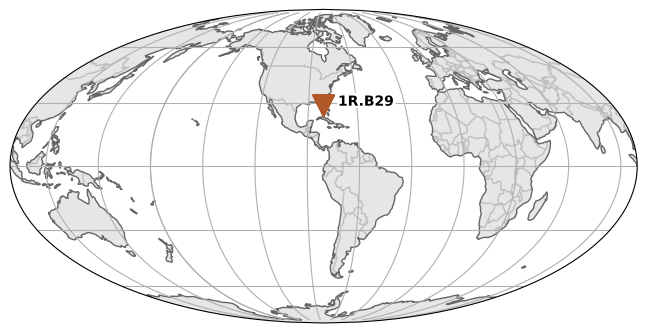

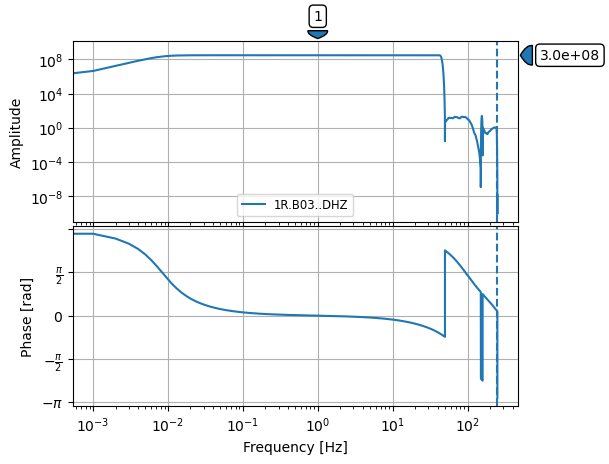

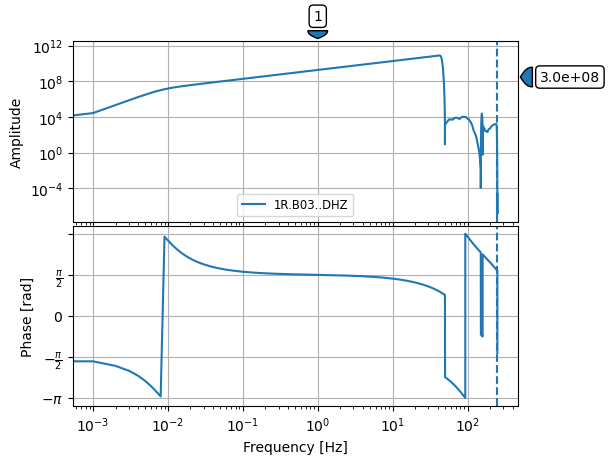

In [147]:
# TO DO

# PERFORMED ABOVE
# from obspy.core.inventory import Inventory
# fill in - create Inventory object and add Network object to it
inventory.plot();
inventory.plot_response(min_freq=0.001, output="VEL",station="B03",channel="DHZ");
inventory.plot_response(min_freq=0.001, output="DISP",station="B03",channel="DHZ");
inventory.write("ksc_inventory.xml", format="STATIONXML")

## Step 5 — Quick check: read back the StationXML

In [148]:
from obspy import read_inventory

inv2 = read_inventory("ksc_inventory.xml")
print(inv2)

Inventory created at 2026-03-07T18:16:03.442930Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: KSC Seismic Network Deployment
	Contains:
		Networks (1):
			1R
		Stations (10):
			1R.B01 (B01)
			1R.B03 (B03)
			1R.B05 (B05)
			1R.B07 (B07)
			1R.B12 (B12)
			1R.B14 (B14)
			1R.B20 (B20)
			1R.B23 (B23)
			1R.B24 (B24)
			1R.B29 (B29)
		Channels (30):
			1R.B01..DHZ, 1R.B01..DHN, 1R.B01..DHE, 1R.B03..DHZ, 1R.B03..DHN, 
			1R.B03..DHE, 1R.B05..DHZ, 1R.B05..DHN, 1R.B05..DHE, 1R.B07..DHZ, 
			1R.B07..DHN, 1R.B07..DHE, 1R.B12..DHZ, 1R.B12..DHN, 1R.B12..DHE, 
			1R.B14..DHZ, 1R.B14..DHN, 1R.B14..DHE, 1R.B20..DHZ, 1R.B20..DHN, 
			1R.B20..DHE, 1R.B23..DHZ, 1R.B23..DHN, 1R.B23..DHE, 1R.B24..DHZ, 
			1R.B24..DHN, 1R.B24..DHE, 1R.B29..DHZ, 1R.B29..DHN, 1R.B29..DHE


In [149]:
stations_with_response = []
stations_missing_response = []

for sta in inventory.networks[0].stations:
    has_response = any(chan.response for chan in sta.channels)
    if has_response:
        stations_with_response.append(sta.code)
    else:
        stations_missing_response.append(sta.code)

print("=== NRL Response Summary ===")
print(f"Stations with NRL response ({len(stations_with_response)}): {stations_with_response}")
print(f"Stations missing NRL response ({len(stations_missing_response)}): {stations_missing_response}")


=== NRL Response Summary ===
Stations with NRL response (6): ['B03', 'B05', 'B14', 'B23', 'B24', 'B29']
Stations missing NRL response (4): ['B01', 'B07', 'B12', 'B20']


## What to submit

Submit your notebook **and** the generated StationXML file.

### Your short note (2–4 sentences)
At the end of your notebook, include a short note:
- Which stations successfully got responses from the NRL?
- Which stations did not, and why (missing mapping, missing instrument info, etc.)?

# add notes below...

All stations reported a response from NRL (except the Kennedy Space Center Stations).  These stations would need a response for their own instruments.  As I was not able to find the instrument info, I could not fill in the information.

ChatGPT was used to help develop this code and several checks along the way.  Most notably was working with a way to separate out the KSC instruments from the USF ones (which was done fairly lazily using a NaN value check).  It also wrote the code for step 5 as it could write the checks faster than myself.  Other code was sourced from within this workbook or from similar instructions from files 73 or 74.